In [51]:
# Target Return Efficient Frontier (EF) ==================================
# Using 10 Indian Stocks with Yahoo Finance ==================================


!pip install yfinance scipy --quiet


# Import Libraries ==================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

plt.style.use("ggplot")


# Select Same 10 Indian Stocks ==================================


stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "LT.NS",
    "ITC.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "HINDUNILVR.NS"
]


# Download Historical Prices ==================================


prices = yf.download(
    stocks,
    start="2019-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

print("Price Data")
display(prices.head())

Price Data


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2019-01-01,280.425415,496.185852,1591.314209,350.957031,541.725891,196.502701,1283.006226,496.196320,271.551178,1561.000244
2019-01-02,274.413177,491.658569,1576.736206,351.777130,544.983948,195.043030,1268.413696,489.733917,266.384796,1577.817993
2019-01-03,275.159241,487.800995,1580.093872,350.474609,545.065491,193.826584,1241.274658,483.691925,263.846954,1558.662354
2019-01-04,283.014648,489.106140,1574.174194,352.356049,538.467712,195.286301,1235.090576,486.303406,269.783722,1539.711670
2019-01-07,285.208923,489.845215,1577.045654,354.768097,547.142822,195.772842,1231.308838,489.003540,268.560089,1556.980347


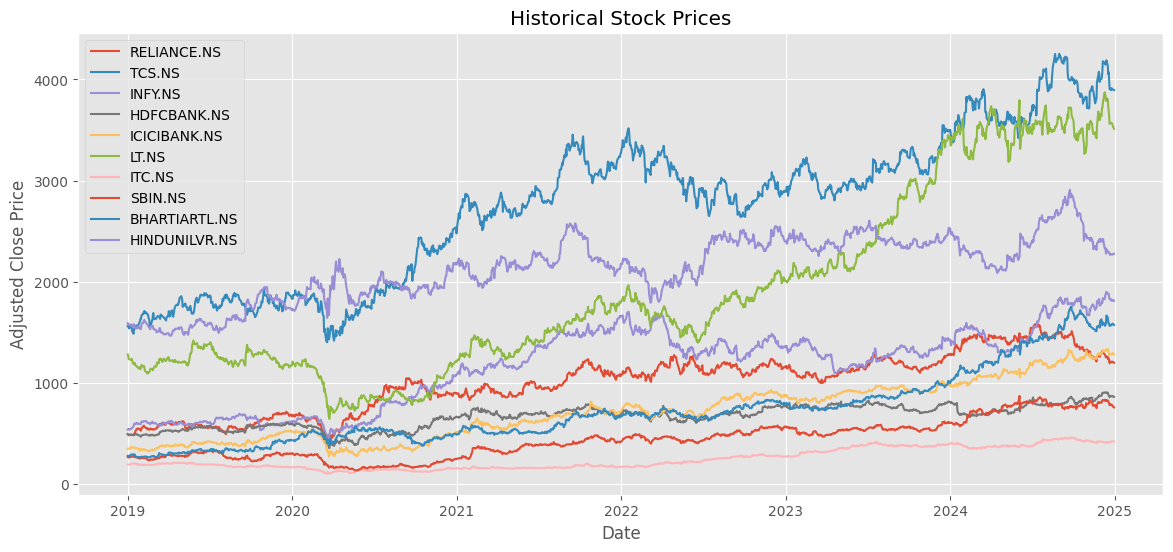

In [52]:
# Plot Stock Prices ==================================


plt.figure(figsize=(14,6))

for stock in stocks:
    plt.plot(prices.index, prices[stock], label=stock)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()

plt.show()

In [53]:
# Daily Returns ==================================


returns = prices.pct_change().dropna()

print("\nDaily Returns")
display(returns.head())


# Expected Annual Returns ===================================

expected_returns = returns.mean() * 252

print("\nExpected Annual Returns")
display(expected_returns)


Daily Returns


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2019-01-02,-0.021440,-0.009124,-0.009161,0.002337,0.006014,-0.007428,-0.011374,-0.013024,-0.019025,0.010774
2019-01-03,0.002719,-0.007846,0.002130,-0.003703,0.000150,-0.006237,-0.021396,-0.012337,-0.009527,-0.012141
2019-01-04,0.028549,0.002676,-0.003746,0.005368,-0.012105,0.007531,-0.004982,0.005399,0.022501,-0.012158
2019-01-07,0.007753,0.001511,0.001824,0.006845,0.016111,0.002491,-0.003062,0.005552,-0.004536,0.011216
2019-01-08,0.013233,-0.008323,-0.007900,0.033859,-0.002457,0.009231,-0.001156,-0.000090,0.030375,-0.002292



Expected Annual Returns


,0
Ticker,
BHARTIARTL.NS,0.337956
HDFCBANK.NS,0.128586
HINDUNILVR.NS,0.087723
ICICIBANK.NS,0.270120
INFY.NS,0.244821
ITC.NS,0.162428
LT.NS,0.211567
RELIANCE.NS,0.193305
SBIN.NS,0.230885


In [54]:
# Annual Covariance Matrix ===================================


cov_matrix = returns.cov() * 252

print("\nAnnual Covariance Matrix")
display(cov_matrix)


Annual Covariance Matrix


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Ticker,,,,,,,,,,
BHARTIARTL.NS,0.088316,0.024906,0.015105,0.031748,0.021425,0.019496,0.028550,0.025982,0.033553,0.017083
HDFCBANK.NS,0.024906,0.068510,0.016077,0.050795,0.022487,0.019487,0.037104,0.031928,0.044639,0.017529
HINDUNILVR.NS,0.015105,0.016077,0.053762,0.018305,0.018281,0.016099,0.016611,0.020899,0.015332,0.016566
ICICIBANK.NS,0.031748,0.050795,0.018305,0.097401,0.026491,0.026219,0.046958,0.037386,0.068442,0.021375
INFY.NS,0.021425,0.022487,0.018281,0.026491,0.077578,0.014684,0.023111,0.025231,0.022667,0.043415
ITC.NS,0.019496,0.019487,0.016099,0.026219,0.014684,0.062973,0.024818,0.020691,0.033164,0.013243
LT.NS,0.028550,0.037104,0.016611,0.046958,0.023111,0.024818,0.079487,0.031836,0.050512,0.019002
RELIANCE.NS,0.025982,0.031928,0.020899,0.037386,0.025231,0.020691,0.031836,0.085900,0.039708,0.024489
SBIN.NS,0.033553,0.044639,0.015332,0.068442,0.022667,0.033164,0.050512,0.039708,0.110994,0.019378


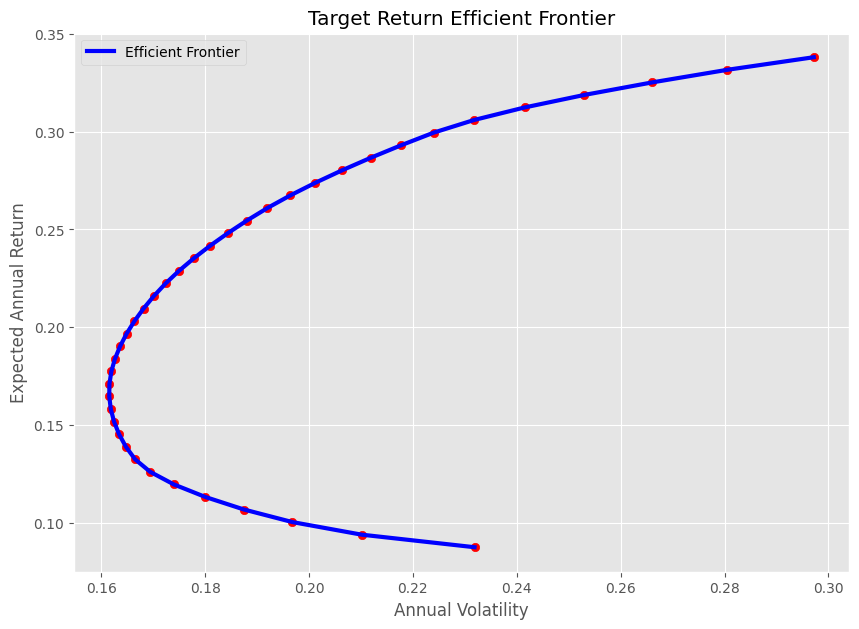

In [55]:
# Portfolio Return ===================================


def portfolio_return(weights):

    return np.dot(weights, expected_returns)


# Portfolio Volatility ===================================


def portfolio_volatility(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )


# Optimization Settings ===================================


n_assets = len(stocks)

initial_weights = np.ones(n_assets) / n_assets

bounds = tuple((0,1) for _ in range(n_assets))


# Target Returns ===================================


target_returns = np.linspace(
    expected_returns.min(),
    expected_returns.max(),
    40
)

frontier_returns = []
frontier_volatility = []
frontier_weights = []


# Solve Optimization For Each Target Return ===================================


for target in target_returns:

    constraints = (

        {
            "type":"eq",
            "fun":lambda w: np.sum(w)-1
        },

        {
            "type":"eq",
            "fun":lambda w,target=target:
                portfolio_return(w)-target
        }

    )

    result = minimize(

        portfolio_volatility,

        initial_weights,

        method="SLSQP",

        bounds=bounds,

        constraints=constraints

    )

    if result.success:

        frontier_returns.append(
            portfolio_return(result.x)
        )

        frontier_volatility.append(
            portfolio_volatility(result.x)
        )

        frontier_weights.append(result.x)


# Convert To Arrays ===================================


frontier_returns = np.array(frontier_returns)

frontier_volatility = np.array(frontier_volatility)


# Plot Efficient Frontier ===================================


plt.figure(figsize=(10,7))

plt.plot(
    frontier_volatility,
    frontier_returns,
    color="blue",
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    frontier_volatility,
    frontier_returns,
    color="red"
)

plt.xlabel("Annual Volatility")

plt.ylabel("Expected Annual Return")

plt.title("Target Return Efficient Frontier")

plt.legend()

plt.grid(True)

plt.show()


In [56]:
# Show Few Portfolios Along Frontier ===================================


portfolio_df = pd.DataFrame({

    "Target Return": frontier_returns,

    "Volatility": frontier_volatility

})

print("\nEfficient Frontier Portfolios")
display(portfolio_df.head(10))


Efficient Frontier Portfolios


,Target Return,Volatility
0,0.087723,0.231866
1,0.094140,0.210117
2,0.100556,0.196811
3,0.106972,0.187483
4,0.113388,0.180035
5,0.119805,0.173964
6,0.126221,0.169418
7,0.132637,0.166506
8,0.139053,0.164739
9,0.145469,0.163419


In [57]:
# Show Lowest Risk Portfolio (GMV) ===================================


gmv_index = np.argmin(frontier_volatility)

print("="*60)
print("GLOBAL MINIMUM VARIANCE PORTFOLIO")
print("="*60)

print(f"Expected Return : {frontier_returns[gmv_index]:.2%}")
print(f"Volatility      : {frontier_volatility[gmv_index]:.2%}")

gmv_weights = pd.DataFrame({

    "Stock": stocks,

    "Weight": frontier_weights[gmv_index]

})

gmv_weights["Weight (%)"] = gmv_weights["Weight"]*100

display(
    gmv_weights.sort_values(
        "Weight",
        ascending=False
    )
)


# Show Highest Return Portfolio ===================================


max_return_index = np.argmax(frontier_returns)

print("="*60)
print("HIGHEST TARGET RETURN PORTFOLIO")
print("="*60)

print(f"Expected Return : {frontier_returns[max_return_index]:.2%}")
print(f"Volatility      : {frontier_volatility[max_return_index]:.2%}")

high_return_weights = pd.DataFrame({

    "Stock": stocks,

    "Weight": frontier_weights[max_return_index]

})

high_return_weights["Weight (%)"] = high_return_weights["Weight"]*100

display(
    high_return_weights.sort_values(
        "Weight",
        ascending=False
    )
)

GLOBAL MINIMUM VARIANCE PORTFOLIO
Expected Return : 16.47%
Volatility      : 16.15%


,Stock,Weight,Weight (%)
2,INFY.NS,0.266705,26.670541
9,HINDUNILVR.NS,0.209967,20.996749
5,LT.NS,0.199421,19.942146
1,TCS.NS,0.129274,12.927363
0,RELIANCE.NS,0.093265,9.326507
6,ITC.NS,0.043631,4.363088
4,ICICIBANK.NS,0.029709,2.970929
7,SBIN.NS,0.028027,2.802677
3,HDFCBANK.NS,0.000000,0.000000
8,BHARTIARTL.NS,0.000000,0.000000


HIGHEST TARGET RETURN PORTFOLIO
Expected Return : 33.80%
Volatility      : 29.72%


,Stock,Weight,Weight (%)
0,RELIANCE.NS,1.000000e+00,1.000000e+02
3,HDFCBANK.NS,1.317882e-08,1.317882e-06
9,HINDUNILVR.NS,5.689893e-16,5.689893e-14
6,ITC.NS,1.387779e-16,1.387779e-14
5,LT.NS,1.110223e-16,1.110223e-14
1,TCS.NS,9.714451e-17,9.714451e-15
4,ICICIBANK.NS,0.000000e+00,0.000000e+00
2,INFY.NS,0.000000e+00,0.000000e+00
7,SBIN.NS,0.000000e+00,0.000000e+00
8,BHARTIARTL.NS,0.000000e+00,0.000000e+00
